# Feature Exploration — Bitcoin Price Prediction

This notebook visualises every feature used by the **Random Forest** model and explains **why** each one was chosen over common alternatives (rolling averages, Bollinger Bands, etc.).

**Features at a glance**

| Group | Features | Purpose |
|---|---|---|
| Lag window | `lag_1` … `lag_20` | Previous 20 closing prices — RF flat feature vector |
| Volatility | `std30` | 30-day rolling standard deviation |
| Momentum | `rsi14` | Relative Strength Index (0–100) |
| Trend | `macd`, `macd_sig` | MACD line + signal line |
| Return | `return` | Previous day's % change |

**Total: 25 features** (20 lags + 5 technical indicators)

All features are **shifted by 1 day** (`.shift(1)`) so no future information leaks into training.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
from datetime import date

# ── Global plot style ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FB",
    "axes.edgecolor": "#D0D7E3",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#E4EAF2",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.grid": True,
    "font.size": 11,
})

# ── Shared color palette (consistent across all notebooks) ───────────
C = {
    "price":   "#6C5CE7",   # medium purple  — BTC price line
    "feature": "#3B82F6",   # strong blue    — features the RF model uses
    "alt1":    "#94A3B8",   # medium gray    — alternative approaches (not used)
    "alt2":    "#64748B",   # dark slate     — second alternative / bearish bars
    "signal":  "#818CF8",   # light indigo   — secondary signals and thresholds
    "zero":    "#CBD5E1",   # light gray     — zero lines, neutral reference
    "shade":   "#EEF2FF",   # very light blue— area shading
}

# ── Download full history (2015 → today) ─────────────────────────────
raw = yf.download("BTC-USD", start="2015-01-01", progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
df = raw[["Close"]].copy()
print(f"Downloaded {len(df)} daily closes  ({df.index[0].date()} → {df.index[-1].date()})")


Downloaded 4136 daily closes  (2015-01-01 → 2026-04-28)


In [2]:
# ── Helpers (mirrors retrain.py / app.py exactly) ────────────────────

def _rsi(series, period=14):
    delta = series.diff()
    up    = delta.clip(lower=0).rolling(period).mean()
    down  = -delta.clip(upper=0).rolling(period).mean()
    return 100 - (100 / (1 + up / down))

def _macd(series, a=12, b=26, c=9):
    ema_a = series.ewm(span=a, adjust=False).mean()
    ema_b = series.ewm(span=b, adjust=False).mean()
    line  = ema_a - ema_b
    sig   = line.ewm(span=c, adjust=False).mean()
    return line, sig

# Build all features (shift=1 → no lookahead)
d = df.copy()
d["return"]   = d["Close"].pct_change().shift(1)
d["std30"]    = d["Close"].rolling(30).std().shift(1)
d["rsi14"]    = _rsi(d["Close"]).shift(1)
ml, ms        = _macd(d["Close"])
d["macd"]     = ml.shift(1)
d["macd_sig"] = ms.shift(1)

# Lag features — 20 lags matching the RF feature set in notebook 02
for i in range(1, 21):
    d[f"lag_{i}"] = d["Close"].shift(i)

d = d.dropna().reset_index()
print(f"Feature matrix shape: {d.shape}  (rows × columns)")
print(d[["Date", "Close", "return", "std30", "rsi14", "macd", "macd_sig", "lag_1", "lag_20"]].tail(3).to_string(index=False))


Feature matrix shape: (4106, 27)  (rows × columns)
      Date        Close    return       std30     rsi14        macd    macd_sig        lag_1       lag_20
2026-04-26 78657.539062  0.002023 4157.679944 62.707081 2043.759964 1765.984998 77612.015625 68859.828125
2026-04-27 77366.625000  0.013471 4183.127086 73.695541 2099.515626 1832.691124 78657.539062 71940.703125
2026-04-28 76448.968750 -0.016412 4110.149242 60.120604 2016.293834 1869.411666 77366.625000 71123.359375


---

## Feature 1 — Lag Window (`lag_1` … `lag_20`)

**What it is:** The raw closing prices for the previous 1 to 20 trading days.  
`lag_1` = yesterday's close, `lag_2` = two days ago, …, `lag_20` = 20 trading days ago (~1 calendar month).

**How the Random Forest uses it:**  
Each lag is a separate column in the flat feature matrix. The RF learns which *combinations* of these values are predictive of tomorrow's log-return — e.g. a decision tree can split on "lag_1 < lag_5 < lag_10" (a recent uptrend). Unlike a sequence model, the RF does not exploit temporal ordering through memory cells, but with 20 explicit lag values it can detect momentum, reversals, and multi-week patterns through feature interactions across hundreds of trees.

**Why 20 lags?**  
20 trading days ≈ 1 calendar month of memory. Experiments in `01-compare-models.ipynb` showed no meaningful improvement in log-return RMSE beyond 20 lags for tree-based models; adding more only increases dimensionality without clear gain.

**Why not a rolling average (SMA/EMA)?**

A simple moving average *compresses* 20 days into a single number, permanently discarding the gradient of individual price swings — precisely the signal the RF uses to distinguish a steady rise from a spike-and-retrace.

| Approach | What you keep | What you lose |
|---|---|---|
| **Lag window (ours)** | Full price history, exact values, gradient | Storage (20 columns) |
| Rolling mean (SMA) | Smoothed trend | Exact values, gradient, amplitude |
| EMA | Recency-weighted trend | Exact values, gradient, amplitude |
| Bollinger Bands | Trend + 2σ envelope | Exact values, gradient, granularity |

The lag window is the raw material from which the RF extracts implicit trends — it is strictly more expressive than any scalar summary.


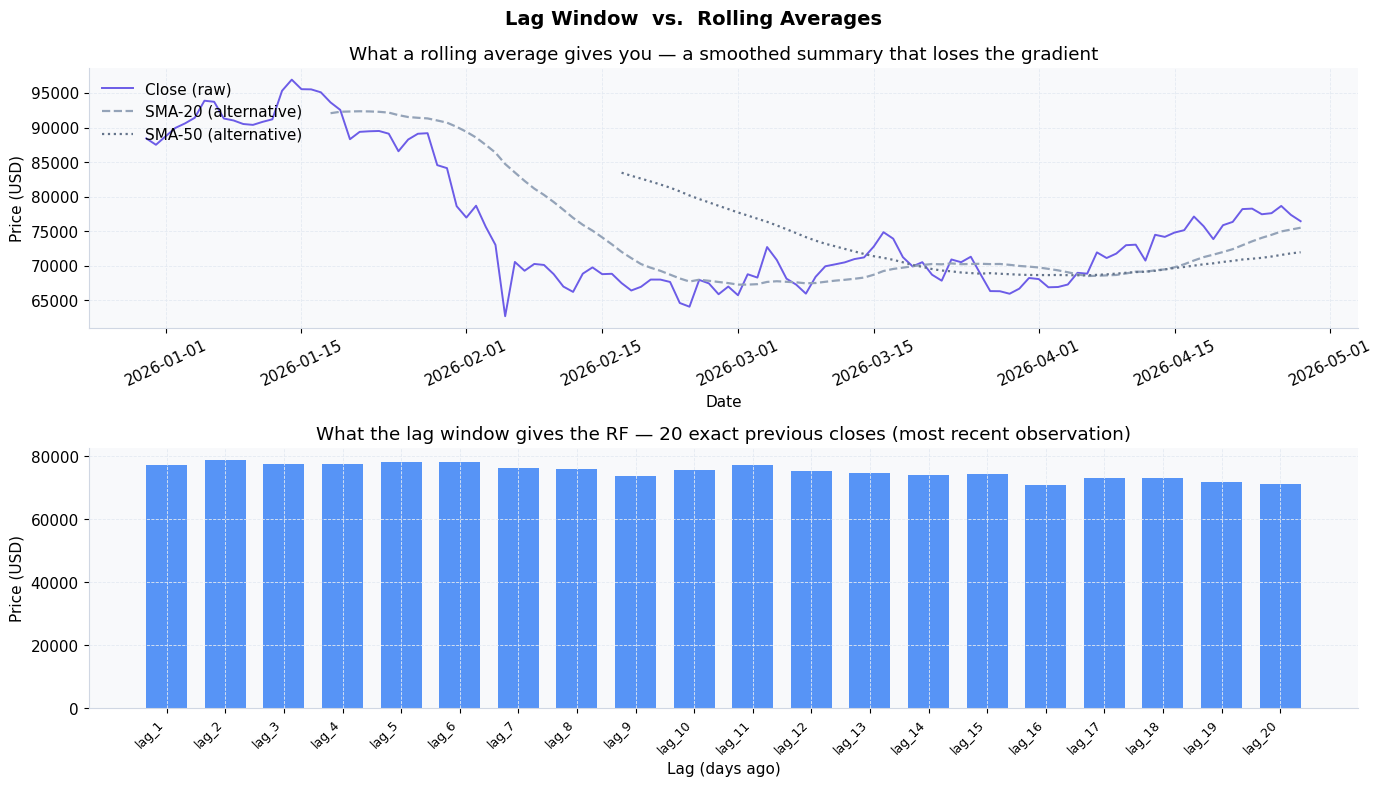

The SMA collapses all those bars into ONE number.  The lag window preserves each individually.


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Lag Window  vs.  Rolling Averages", fontsize=14, fontweight="bold")

recent = d.tail(120).copy()

# ── Top: raw close + SMA alternatives ────────────────────────────────
ax = axes[0]
ax.plot(recent["Date"], recent["Close"], color=C["price"], lw=1.4, label="Close (raw)")
ax.plot(recent["Date"], recent["Close"].rolling(20).mean(), color=C["alt1"], lw=1.6,
        linestyle="--", label="SMA-20 (alternative)")
ax.plot(recent["Date"], recent["Close"].rolling(50).mean(), color=C["alt2"], lw=1.6,
        linestyle=":", label="SMA-50 (alternative)")
ax.set_title("What a rolling average gives you — a smoothed summary that loses the gradient")
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", frameon=False)
ax.tick_params(axis="x", rotation=25)

# ── Bottom: lag features shown as a bar chart ──────────────────────────
ax2 = axes[1]
lag_cols = [f"lag_{i}" for i in range(1, 21)]   # lag_1 … lag_20 (RF feature set)
lag_vals = recent[lag_cols].iloc[-1].values       # last row = most recent observation

ax2.bar(range(1, 21), lag_vals, color=C["feature"], alpha=0.85, width=0.7)
ax2.set_title("What the lag window gives the RF — 20 exact previous closes (most recent observation)")
ax2.set_xlabel("Lag (days ago)")
ax2.set_ylabel("Price (USD)")
ax2.set_xticks(range(1, 21))
ax2.set_xticklabels([f"lag_{i}" for i in range(1, 21)], rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()
print("The SMA collapses all those bars into ONE number.  The lag window preserves each individually.")


---

## Feature 2 — `std30` (30-day rolling standard deviation)

**What it is:** The standard deviation of the closing price over the last 30 days, shifted by 1 day.  
It is a **volatility proxy** — a high value means the price has been moving a lot recently.

**Why not Bollinger Bands (`SMA ± 2σ`)?**

Bollinger Bands combine the mean and the standard deviation into two lines. But the model already receives the full lag window (which implicitly encodes the mean), so adding `(mean ± 2σ)` as features would be partially redundant. `std30` in isolation gives the model a clean, single-number signal for "how turbulent is the market right now?" without the noise of the redundant mean term.

**Why not GARCH volatility?**  
GARCH models are more theoretically accurate for financial volatility but require fitting a separate model per prediction step, add a heavy dependency, and have not been shown to consistently outperform simple rolling std in daily BTC prediction tasks.


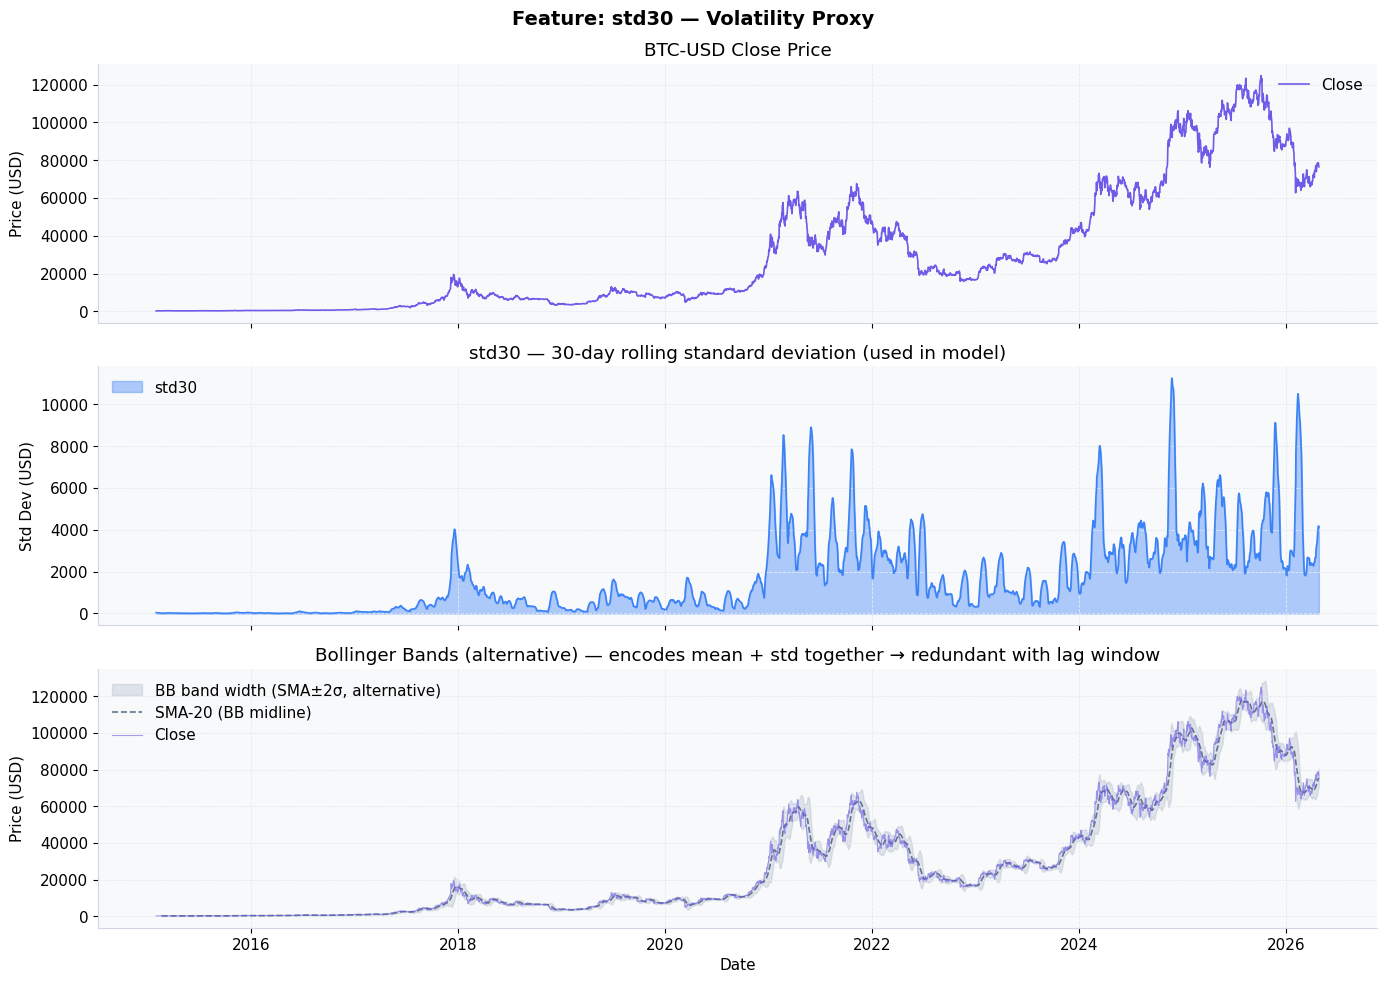

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Feature: std30 — Volatility Proxy", fontsize=14, fontweight="bold")

# ── Panel 1: Close price ──────────────────────────────────────────────
axes[0].plot(d["Date"], d["Close"], color=C["price"], lw=1.2, label="Close")
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("BTC-USD Close Price")
axes[0].legend(frameon=False)

# ── Panel 2: std30 ────────────────────────────────────────────────────
axes[1].fill_between(d["Date"], d["std30"], color=C["feature"], alpha=0.4, label="std30")
axes[1].plot(d["Date"], d["std30"], color=C["feature"], lw=1.2)
axes[1].set_ylabel("Std Dev (USD)")
axes[1].set_title("std30 — 30-day rolling standard deviation (used in model)")
axes[1].legend(frameon=False)

# ── Panel 3: Bollinger Bands width (alternative — for comparison) ────
bb_mid   = d["Close"].rolling(20).mean()
bb_upper = bb_mid + 2 * d["Close"].rolling(20).std()
bb_lower = bb_mid - 2 * d["Close"].rolling(20).std()
bb_width = bb_upper - bb_lower   # same information as std, but scaled by 4

axes[2].fill_between(d["Date"], bb_lower, bb_upper, color=C["alt1"], alpha=0.25, label="BB band width (SMA±2σ, alternative)")
axes[2].plot(d["Date"], bb_mid, color=C["alt2"], lw=1.2, linestyle="--", label="SMA-20 (BB midline)")
axes[2].plot(d["Date"], d["Close"], color=C["price"], lw=0.8, alpha=0.6, label="Close")
axes[2].set_ylabel("Price (USD)")
axes[2].set_title("Bollinger Bands (alternative) — encodes mean + std together → redundant with lag window")
axes[2].legend(loc="upper left", frameon=False)
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


---

## Feature 3 — `rsi14` (Relative Strength Index, 14 days)

**Formula:**

$$RSI = 100 - \frac{100}{1 + \frac{\text{avg gain (14d)}}{\text{avg loss (14d)}}}$$

**What it encodes:**
- RSI → 70: overbought (price has risen fast, reversal risk)
- RSI → 30: oversold (price has fallen fast, potential bounce)
- RSI ≈ 50: neutral momentum

**Why 14 days?**  
14 is the industry default introduced by J. Welles Wilder in 1978. It balances noise (too short → whipsaws) against lag (too long → misses reversals). We use it unchanged because it is the most widely used and therefore most likely to capture crowd behaviour patterns that the market itself reacts to.

**Why not Stochastic Oscillator or Williams %R?**  
All three measure the same underlying concept (overbought/oversold momentum). RSI is bounded 0–100, numerically stable, and directly interpretable. The others offer no proven advantage on daily BTC data and would add correlation noise.

**Why not a simple "return over N days"?**  
That would measure direction and magnitude but not relative strength. RSI normalises by both gains and losses, making it scale-invariant — it reads the same whether BTC is at $5 000 or $100 000.


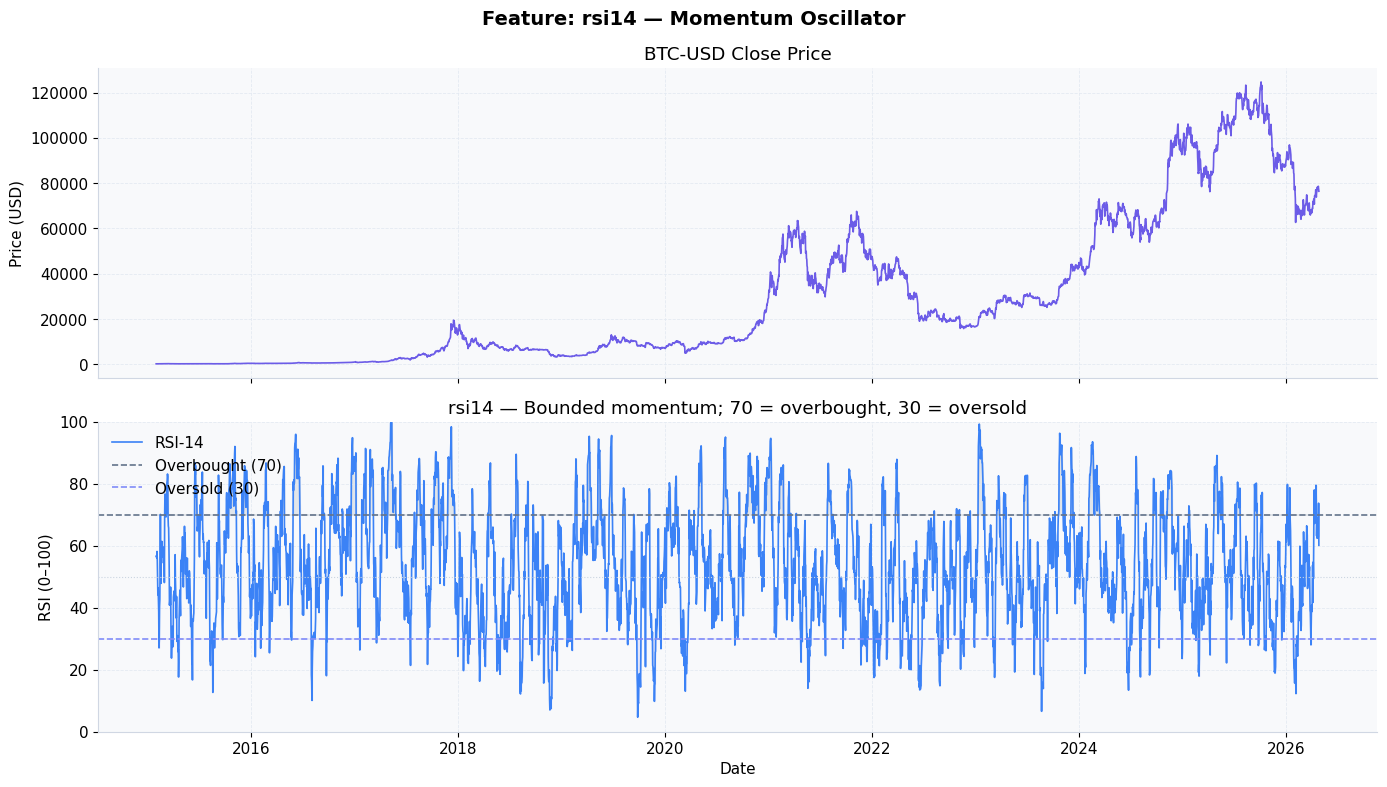

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Feature: rsi14 — Momentum Oscillator", fontsize=14, fontweight="bold")

# ── Panel 1: Close price ──────────────────────────────────────────────
axes[0].plot(d["Date"], d["Close"], color=C["price"], lw=1.2)
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("BTC-USD Close Price")

# ── Panel 2: RSI ──────────────────────────────────────────────────────
axes[1].plot(d["Date"], d["rsi14"], color=C["feature"], lw=1.2, label="RSI-14")
axes[1].axhline(70, color=C["alt2"], lw=1.2, linestyle="--", label="Overbought (70)")
axes[1].axhline(30, color=C["signal"], lw=1.2, linestyle="--", label="Oversold (30)")
axes[1].axhline(50, color=C["zero"],  lw=0.8, linestyle=":")

# Shade overbought / oversold zones
axes[1].fill_between(d["Date"], 70, d["rsi14"].clip(lower=70), color=C["alt2"],   alpha=0.15)
axes[1].fill_between(d["Date"], d["rsi14"].clip(upper=30), 30, color=C["signal"], alpha=0.15)

axes[1].set_ylim(0, 100)
axes[1].set_ylabel("RSI (0–100)")
axes[1].set_title("rsi14 — Bounded momentum; 70 = overbought, 30 = oversold")
axes[1].legend(loc="upper left", frameon=False)
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


---

## Features 4 & 5 — `macd` and `macd_sig` (MACD Indicator)

**Formulas:**

$$\text{MACD line} = EMA_{12}(\text{Close}) - EMA_{26}(\text{Close})$$

$$\text{Signal line} = EMA_9(\text{MACD line})$$

**What they encode:**
- **MACD line** > 0: short-term momentum above long-term → bullish
- **MACD line** < 0: short-term momentum below long-term → bearish
- **Crossover** (MACD crosses signal from below): classic buy signal in technical analysis
- **Crossover** (MACD crosses signal from above): classic sell signal

**Why two features instead of one?**  
The model needs both to detect crossovers. MACD alone tells you the absolute momentum gap; the signal line is a smoothed version that filters noise. The *difference* between them (MACD histogram = `macd - macd_sig`) is what traders watch for crossovers, but we feed both separately so the RF can exploit any nonlinear combination — the histogram effect emerges naturally from the tree splits without us having to pre-compute it.

**Why not just SMA(12) − SMA(26)?**  
EMA weights recent days more heavily, reacting faster to price changes than SMA. For a volatile asset like BTC that can move 10% in a day, EMA is more responsive and carries more signal about the current trend direction.

**Why not ADX (Average Directional Index)?**  
ADX measures trend *strength* but not direction — it requires separate +DI and -DI components to be meaningful, adding 3 features for the same purpose. MACD encodes both direction and momentum in 2 features that are simpler to interpret and train on.


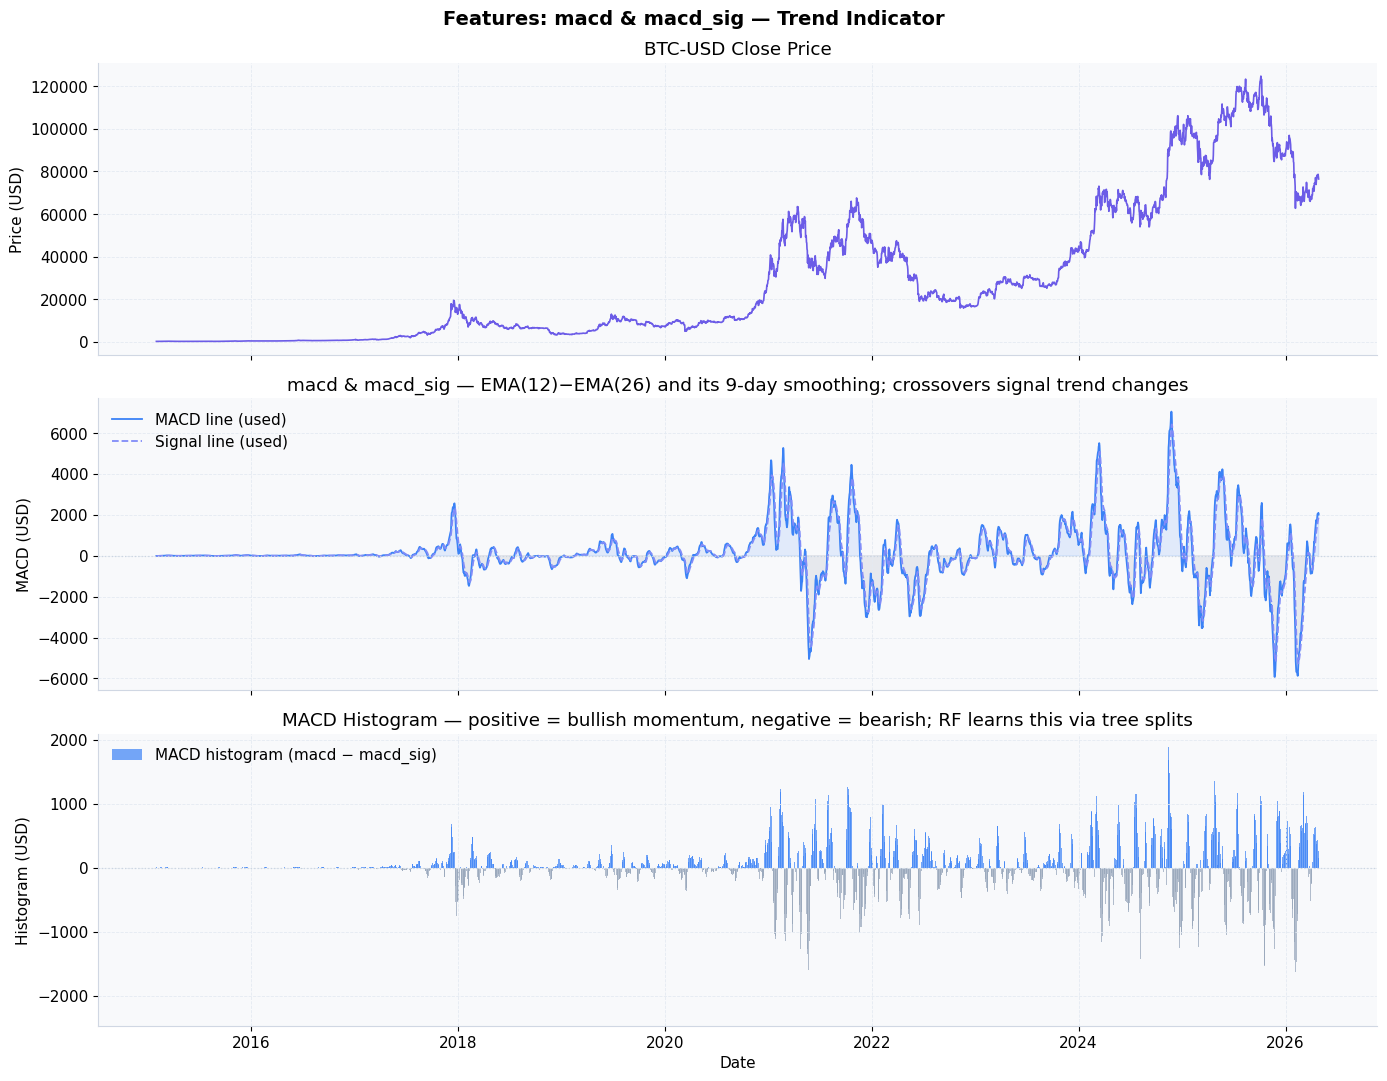

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Features: macd & macd_sig — Trend Indicator", fontsize=14, fontweight="bold")

# ── Panel 1: Close price ──────────────────────────────────────────────
axes[0].plot(d["Date"], d["Close"], color=C["price"], lw=1.2)
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("BTC-USD Close Price")

# ── Panel 2: MACD line + signal line (both used as RF features) ───────
axes[1].plot(d["Date"], d["macd"],     color=C["feature"], lw=1.3, label="MACD line (used)")
axes[1].plot(d["Date"], d["macd_sig"], color=C["signal"],  lw=1.3, linestyle="--", label="Signal line (used)")
axes[1].axhline(0, color=C["zero"], lw=0.9, linestyle=":")
axes[1].fill_between(d["Date"], d["macd"], 0, where=(d["macd"] > 0), color=C["feature"], alpha=0.12)
axes[1].fill_between(d["Date"], d["macd"], 0, where=(d["macd"] < 0), color=C["alt2"],    alpha=0.12)
axes[1].set_ylabel("MACD (USD)")
axes[1].set_title("macd & macd_sig — EMA(12)−EMA(26) and its 9-day smoothing; crossovers signal trend changes")
axes[1].legend(loc="upper left", frameon=False)

# ── Panel 3: Histogram = macd − macd_sig (what traders watch) ────────
hist = d["macd"] - d["macd_sig"]
colors_bar = [C["feature"] if v >= 0 else C["alt1"] for v in hist]
axes[2].bar(d["Date"], hist, color=colors_bar, width=1.5, alpha=0.7, label="MACD histogram (macd − macd_sig)")
axes[2].axhline(0, color=C["zero"], lw=0.9, linestyle=":")
axes[2].set_ylabel("Histogram (USD)")
axes[2].set_title("MACD Histogram — positive = bullish momentum, negative = bearish; RF learns this via tree splits")
axes[2].set_xlabel("Date")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()


---

## Feature 6 — `return` (Previous Day's % Change)

**Formula:**

$$\text{return}[t] = \frac{\text{Close}[t] - \text{Close}[t-1]}{\text{Close}[t-1]}$$

Shifted by 1 day: the model sees yesterday's return, not today's.

**What it encodes:**  
Short-term momentum and direction. A large positive return yesterday means the market was bullish; a large negative return means bearish. This complements the lag window (which gives price levels) by giving the model a direct, scale-free measure of recent directionality.

**Why not use log-return here too?**  
The *target* variable is a log-return (for stationarity). The *feature* is a percentage return — the difference is negligible at small values (<5%) but for extreme BTC moves (±20%) the percentage return is simpler to interpret and the model treats it as a feature to pattern-match against. Both representations contain the same information at typical magnitudes.

**Why not a 5-day or 10-day return?**  
Longer return windows overlap with what the lag window and MACD already capture. Using only the 1-day return keeps it orthogonal and focused on the immediate previous-day signal.


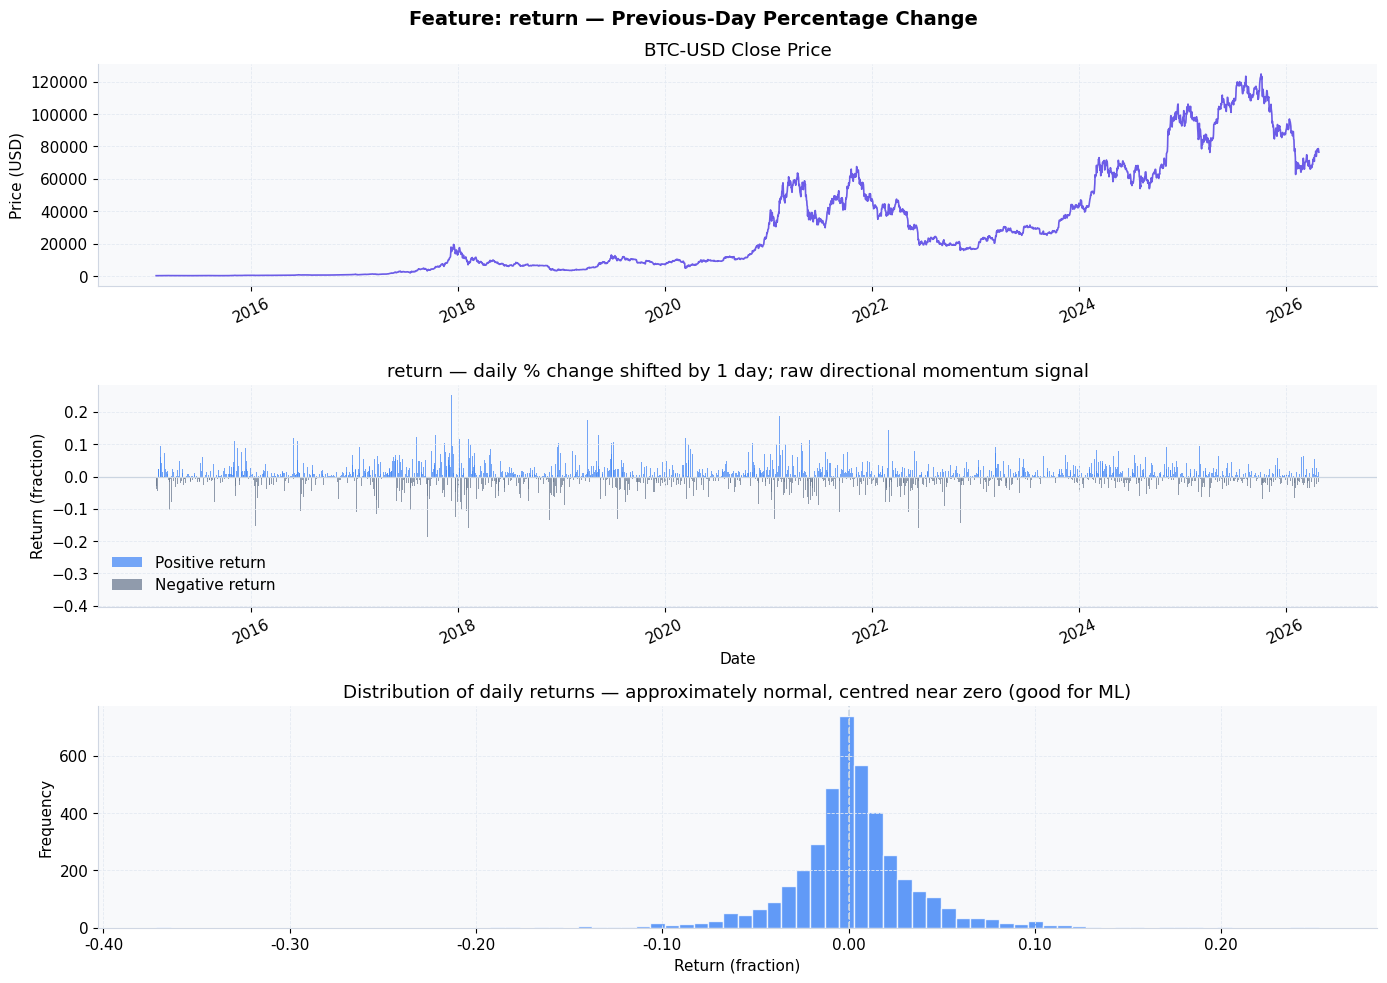

Return stats:  mean=0.0020  std=0.0346  min=-0.372  max=0.252


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Feature: return — Previous-Day Percentage Change", fontsize=14, fontweight="bold")

# ── Panel 1: Close price ──────────────────────────────────────────────
axes[0].plot(d["Date"], d["Close"], color=C["price"], lw=1.2)
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("BTC-USD Close Price")
axes[0].tick_params(axis="x", rotation=25)

# ── Panel 2: daily return ─────────────────────────────────────────────
pos = d["return"] >= 0
axes[1].bar(d["Date"], d["return"].where(pos),  color=C["feature"], width=1.5, alpha=0.7, label="Positive return")
axes[1].bar(d["Date"], d["return"].where(~pos), color=C["alt2"],    width=1.5, alpha=0.7, label="Negative return")
axes[1].axhline(0, color=C["zero"], lw=0.9)
axes[1].set_ylabel("Return (fraction)")
axes[1].set_xlabel("Date")
axes[1].set_title("return — daily % change shifted by 1 day; raw directional momentum signal")
axes[1].legend(frameon=False)
axes[1].tick_params(axis="x", rotation=25)

# ── Panel 3: distribution (its own independent x-axis) ───────────────
returns_clean = d["return"].dropna().values
axes[2].hist(returns_clean, bins=80, color=C["feature"], edgecolor="white", alpha=0.8)
axes[2].axvline(0, color=C["zero"], lw=1.2, linestyle="--")
axes[2].set_xlabel("Return (fraction)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of daily returns — approximately normal, centred near zero (good for ML)")
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

plt.tight_layout()
plt.show()

print(f"Return stats:  mean={d['return'].mean():.4f}  std={d['return'].std():.4f}"
      f"  min={d['return'].min():.3f}  max={d['return'].max():.3f}")


---

## All Features Together — Correlation & Redundancy Check

A healthy feature set has features that are:
1. **Individually informative** (correlated with price or returns)
2. **Not fully redundant** with each other (low inter-feature correlation)

The heatmap below shows the Pearson correlation between all non-lag features plus Close and the target log-return. Features with very high inter-correlation would be candidates for removal; the existing set is designed to be complementary.


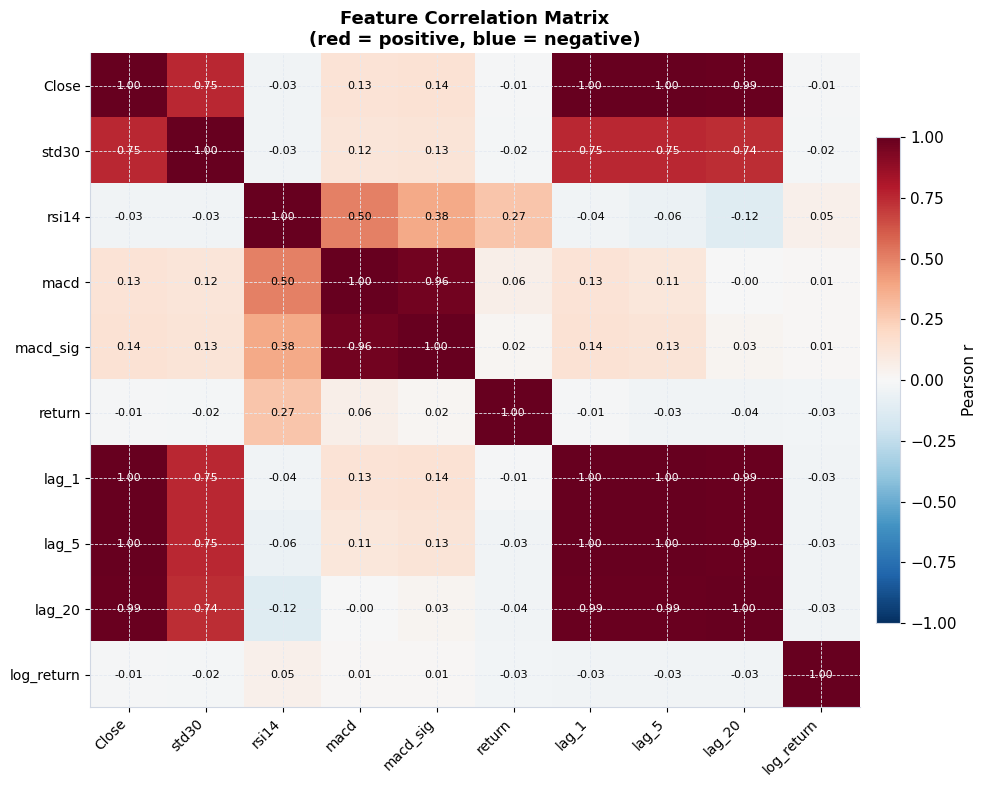

Key observations:
  macd ↔ macd_sig correlation:  0.961  (expected — signal is smoothed MACD)
  lag_1 ↔ log_return:           -0.032  (low — price level ≠ next-day return)
  return ↔ log_return:          -0.027  (moderate — yesterday's return predicts today's)
  rsi14 ↔ std30:                -0.034  (low — orthogonal signals)


In [8]:
import matplotlib.colors as mcolors

# Add log-return (our actual target) to the frame
d["log_return"] = np.log(d["Close"] / d["lag_1"])

# Use only the non-lag features + representative lags (max lag in RF set is lag_20)
overview_cols = ["Close", "std30", "rsi14", "macd", "macd_sig", "return",
                 "lag_1", "lag_5", "lag_20", "log_return"]
corr = d[overview_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Pearson r")

ax.set_xticks(range(len(overview_cols)))
ax.set_yticks(range(len(overview_cols)))
ax.set_xticklabels(overview_cols, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(overview_cols, fontsize=10)

# Annotate cells
for i in range(len(overview_cols)):
    for j in range(len(overview_cols)):
        val = corr.values[i, j]
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=text_color)

ax.set_title("Feature Correlation Matrix\n(red = positive, blue = negative)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Key observations ──────────────────────────────────────────────────
print("Key observations:")
print(f"  macd ↔ macd_sig correlation:  {corr.loc['macd','macd_sig']:.3f}  (expected — signal is smoothed MACD)")
print(f"  lag_1 ↔ log_return:           {corr.loc['lag_1','log_return']:.3f}  (low — price level ≠ next-day return)")
print(f"  return ↔ log_return:          {corr.loc['return','log_return']:.3f}  (moderate — yesterday's return predicts today's)")
print(f"  rsi14 ↔ std30:                {corr.loc['rsi14','std30']:.3f}  (low — orthogonal signals)")


---

## Why These Features and Not Others?

### Summary table

| Alternative | Why not used |
|---|---|
| **SMA / EMA** | A smoothed mean collapses 20 days of price history into a single number, discarding the gradient and exact values that each of the 20 lag features encodes separately. The RF learns trend detection directly from the lag window. |
| **Bollinger Bands** | `mean ± 2σ` — redundant with the lag window (mean) and `std30` (σ). Would add features without new information. |
| **Stochastic Oscillator / Williams %R** | Same concept as RSI (overbought/oversold). RSI is the most widely-traded and numerically cleaner. |
| **ADX (Average Directional Index)** | Needs 3 components (+DI, -DI, ADX); MACD captures direction+strength in 2 features. |
| **OBV (On-Balance Volume)** | Requires volume data, which yfinance provides but is unreliable for crypto (aggregated across exchanges). The current pipeline is price-only for robustness. |
| **GARCH volatility** | More theoretically accurate than std30 but needs a separate model fitted per step; adds a heavy dependency for marginal gain on daily data. |
| **Multi-day returns (5d, 10d)** | Overlap substantially with what the lag window + MACD already captures. Adding them increases correlation noise. |
| **Sentiment / on-chain data** | High signal but require paid APIs, complex pipelines, and are outside scope. The lag window + technical indicators provide a self-contained, reproducible baseline. |

### Design principles followed

1. **No lookahead leakage** — every feature is `.shift(1)`, meaning only data known *before* day `t` is used to predict day `t`.
2. **Orthogonality** — the 5 non-lag features were chosen because they represent distinct concepts (volatility, momentum, trend, direction) with low inter-correlation.
3. **Scale-invariance** — RSI is bounded 0–100; MACD and return are scaled by the `StandardScaler`; the RF sees normalised inputs regardless of whether BTC is at $5K or $100K.
4. **Reproducibility** — all features are derived from `Close` only (no external feeds), ensuring the pipeline works anywhere yfinance works.
